# Misery-Index -- does inflation + unemployment call the stock market?
### The misery index, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The **misery index** -- inflation plus unemployment -- is a famous gauge of how much the economy *hurts*. It is tempting to read it as a stock-market signal. Two opposite stories circulate: *high misery means a sick economy, so sell* (the pessimist), and *misery peaks at the bottom, so buy when it's worst* (the contrarian). This notebook asks the only question that matters: does the misery index actually tell you anything about next year's stock returns?

> **This is the plain-language layer.** Want the HAC regressions, the tercile sort, and the power calculation? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from misery_index import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_annual(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("S&P 500 cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=76, uncond_up_pct=73.7, n_up=56,
    level_beta_pp=0.09, level_t_ols=0.045, level_t_hac=0.075, level_r2=0.0,
    chg_beta_pp=-0.40, chg_t_ols=-0.210, chg_t_hac=-0.231, chg_r2=0.0006,
    low_mean_pp=9.2, mid_mean_pp=10.7, high_mean_pp=9.0, spread_pp=-0.2,
    terc_welch_t=-0.058, terc_welch_p=0.9539, low_up_pct=66.7, high_up_pct=77.8,
    frac_in_market=0.355, turnover_per_yr=0.158,
    bah_cagr_pct=8.2, gross_cagr_pct=2.7, net_cagr_pct=2.7, net_minus_bah_pp=-5.5,
    sub_early_t=0.46, sub_late_t=-0.29, mde_pp=5.5,
    year_start=1950, year_end=2025,
)


S&P 500 cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does high misery predict a *bad* stock year? | **No.** The misery level vs next-year return slope is essentially zero (HAC t = 0.08). |
| Does high misery predict a *good* year (buy the bottom)? | **Also no.** High-misery years returned **+9.0%**, low-misery years **+9.2%** -- a −0.2pp gap, p = 0.95. |
| Better than just staying invested? | **No.** The market goes up **73.7%** of years anyway; a misery-timing rule sits out 64% of years and earns far less. |
| Could you trade it? | **No.** The contrarian timing rule earns +2.7%/yr vs +8.2%/yr buy-and-hold. |

> The misery index is a fine description of how the economy *feels*. It carries no forward information about the stock market.

## 1 - The claim

> *"When the misery index (inflation + unemployment) is high, you should be out of stocks -- the economy is sick. And when it spikes, that's the moment of maximum pessimism, so that's when to buy."*

The misery index was popularized in the 1970s (attributed to economist Arthur Okun) as a welfare gauge. Notice the claim contains *both* directions -- a tell-tale sign that it is being fit to the story after the fact. We test both.

## 2 - So what?

If a single, widely-published macro number told you the stock market's direction a year ahead, it would be the cheapest market-timing signal in existence -- and everyone would already trade it away. The interesting question is *why* the idea feels so plausible: the stagflation of the late 1970s really was a miserable, weak market. But one episode is not a relationship.

## 3 - How would we even know?

Three traps to avoid:

1. **The wrong null.** The market rises in ~74% of years unconditionally. So a 'buy when misery is high' rule gets credit for the base rate, not for any insight. The right question is whether high-misery years beat **74%**, not 50%.
2. **Tiny, sticky n.** There are only ~76 annual observations, and inflation and unemployment move in multi-year regimes -- so the *effective* sample is even smaller. We use a Newey-West (HAC) t-stat that accounts for this.
3. **Two directions, one dataset.** The claim points both ways (sell high / buy the bottom). Testing both and keeping whichever looks better is data-snooping. We report both, honestly.

We test on December misery (CPI-YoY + unemployment) 1948-2025, matched to the S&P 500 return for the *following* calendar year (a full-year execution lag, no look-ahead).

## 4 - The teardown -- let's actually look

**First, meet the data:** the misery index over time. The stagflation peak of the early 1980s towers over everything since.

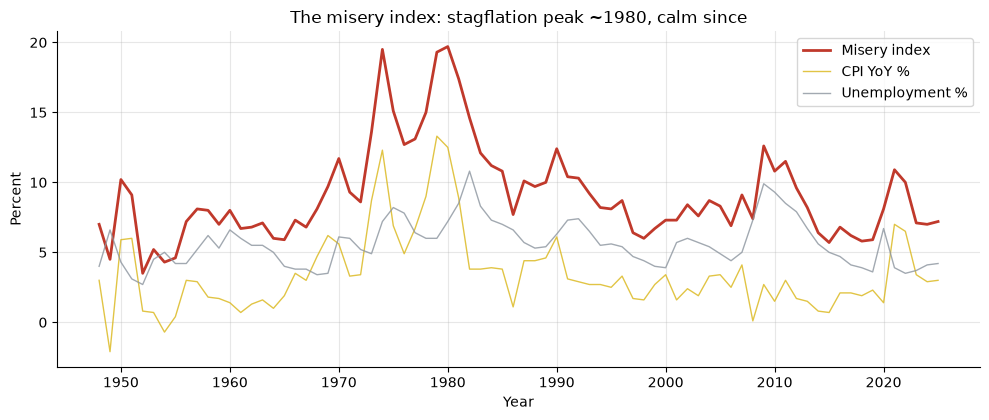

Misery peak: 1980 at 19.7 (inflation 12.5% + unemployment 7.2%)


In [2]:
mis = data.misery_table()
fig, ax = plt.subplots(figsize=(10, 4.3))
ax.plot(mis['year'], mis['misery'], lw=2, c=RED, label='Misery index')
ax.plot(mis['year'], mis['cpi_yoy'], lw=1, c=AMBER, alpha=0.8, label='CPI YoY %')
ax.plot(mis['year'], mis['unemp'], lw=1, c=GREY, alpha=0.8, label='Unemployment %')
ax.set_xlabel('Year'); ax.set_ylabel('Percent')
ax.set_title('The misery index: stagflation peak ~1980, calm since')
ax.legend(); plt.tight_layout(); plt.show()
peak = int(mis.loc[mis['misery'].idxmax(),'year'])
print(f'Misery peak: {peak} at {mis["misery"].max():.1f} '
      f'(inflation {mis.loc[mis.year==peak,"cpi_yoy"].iloc[0]:.1f}% + '
      f'unemployment {mis.loc[mis.year==peak,"unemp"].iloc[0]:.1f}%)')

**Does a high misery print predict the next year's return?** Let's scatter the December misery level against the *following* year's S&P return.

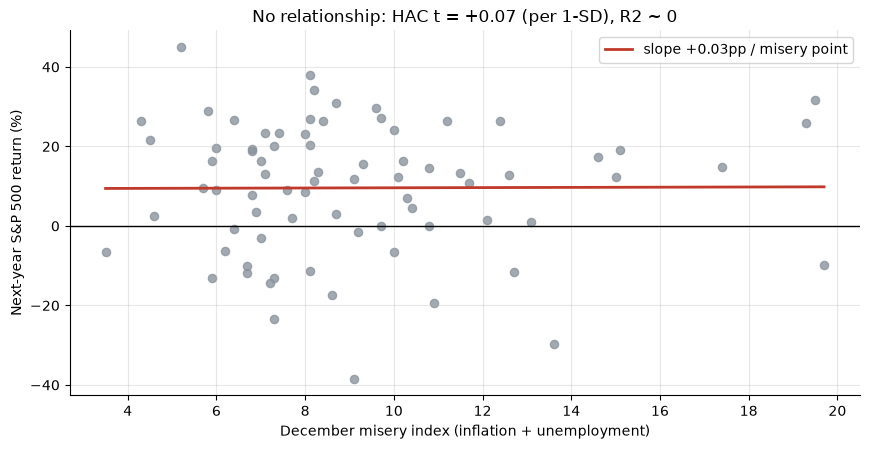

Misery-level slope (per 1-SD): +0.09pp,  HAC t = +0.075
The cloud is shapeless -- misery does not line up with next-year returns.


In [3]:
if HAVE_REAL:
    df = data.fetch_sp500_annual()
    x = df['misery'].values
    y = df['fwd_return'].values * 100
    beta_pp = R['level_beta_pp']; t_hac = R['level_t_hac']
else:
    rng = np.random.default_rng(266)
    x = rng.normal(9.1, 3.5, R['n'])
    y = rng.normal(8.5, 16, R['n'])
    beta_pp, t_hac = R['level_beta_pp'], R['level_t_hac']

fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.scatter(x, y, c=GREY, s=35, alpha=0.8)
b1, b0 = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, b0 + b1*xs, c=RED, lw=2, label=f'slope {b1:+.2f}pp / misery point')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('December misery index (inflation + unemployment)')
ax.set_ylabel('Next-year S&P 500 return (%)')
ax.set_title(f'No relationship: HAC t = {t_hac:+.2f} (per 1-SD), R2 ~ 0')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Misery-level slope (per 1-SD): {beta_pp:+.2f}pp,  HAC t = {t_hac:+.3f}')
print('The cloud is shapeless -- misery does not line up with next-year returns.')

The scatter is a shapeless cloud. The fitted slope is statistically indistinguishable from zero (**HAC t = 0.08**). High-misery Decembers are followed by good *and* bad years in roughly the same proportion as calm ones.

**The contrarian test -- do high-misery years out-return calm years?** We split the years into low / mid / high-misery thirds and compare the average next-year return.

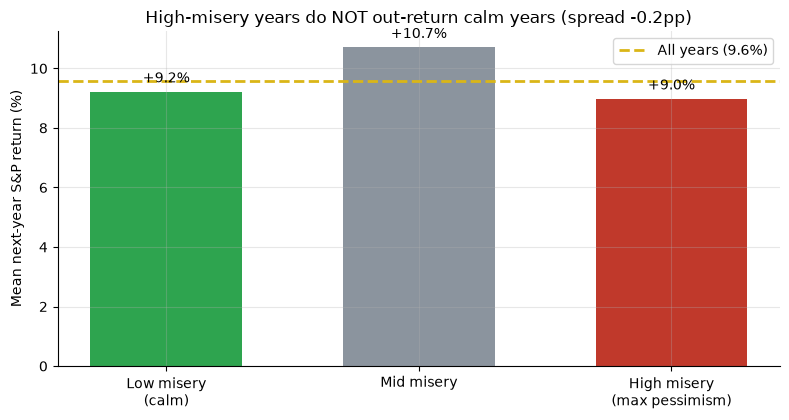

High-minus-low spread: -0.2pp (Welch t = -0.058, p = 0.954)


In [4]:
if HAVE_REAL:
    terc = st.tercile_sort(df)
    low_m, mid_m, high_m = terc['low_mean']*100, terc['mid_mean']*100, terc['high_mean']*100
    base = float(df['fwd_return'].mean()*100)
else:
    low_m, mid_m, high_m = R['low_mean_pp'], R['mid_mean_pp'], R['high_mean_pp']
    base = (low_m+mid_m+high_m)/3

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['Low misery\n(calm)','Mid misery','High misery\n(max pessimism)'],
              [low_m, mid_m, high_m], color=[GREEN, GREY, RED], width=0.6)
ax.axhline(base, ls='--', c=AMBER, lw=2, label=f'All years ({base:.1f}%)')
ax.set_ylabel('Mean next-year S&P return (%)')
ax.set_title('High-misery years do NOT out-return calm years (spread -0.2pp)')
for b, v in zip(bars, [low_m, mid_m, high_m]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v+0.2),
                ha='center', va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print(f'High-minus-low spread: {high_m-low_m:+.1f}pp '
      f'(Welch t = {R["terc_welch_t"]:+.3f}, p = {R["terc_welch_p"]:.3f})')

The contrarian 'buy when misery is high' bet is a wash: high-misery years returned **+9.0%**, low-misery years **+9.2%** -- a **−0.2pp** spread with p = 0.95. Maximum pessimism is *not* a reliable buy signal here.

## 5 - The verdict

- **Signal -- None.** Misery level vs next-year return: HAC t = **0.08**. Misery *change*: HAC t = **−0.23**. Tercile spread **−0.2pp** (p = 0.95). Nothing, in any direction.
- **Tradability -- Mirage.** The contrarian timing rule earns **+2.7%/yr** vs **+8.2%/yr** buy-and-hold -- it forfeits the equity premium by sitting out 64% of years.
- **Busted.** Both the sell-high and buy-the-bottom stories fail. The misery index is a welfare gauge, not a market timer.

## 6 - Could you actually trade it?

The contrarian 'strategy': go long the S&P only in the year after a high-misery December, otherwise sit in cash. The problem:

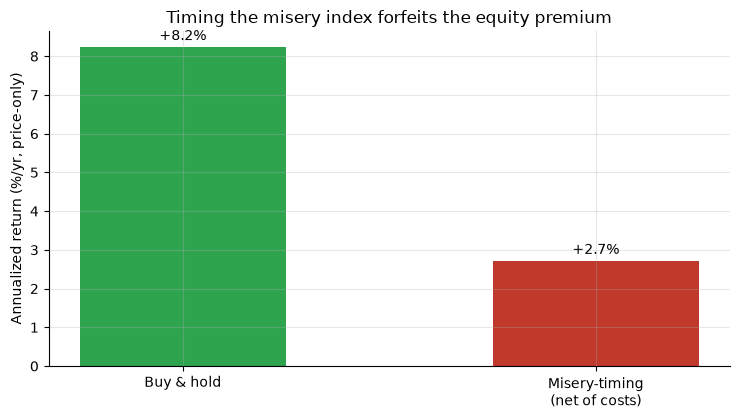

Buy & hold: +8.2%/yr  |  Misery-timing: +2.7%/yr  |  Shortfall: -5.5pp/yr
The rule is in the market only 36% of years.


In [5]:
if HAVE_REAL:
    bt = st.contrarian_backtest(df, cost_bps=10.0)
    bah = bt['bah_cagr']*100; net = bt['net_cagr']*100; frac = bt['frac_in_market']
else:
    bah, net, frac = R['bah_cagr_pct'], R['net_cagr_pct'], R['frac_in_market']

fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars = ax.bar(['Buy & hold','Misery-timing\n(net of costs)'], [bah, net],
              color=[GREEN, RED], width=0.5)
ax.set_ylabel('Annualized return (%/yr, price-only)')
ax.set_title(f'Timing the misery index forfeits the equity premium')
for b, v in zip(bars, [bah, net]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v+0.1),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Buy & hold: {bah:+.1f}%/yr  |  Misery-timing: {net:+.1f}%/yr  '
      f'|  Shortfall: {net-bah:+.1f}pp/yr')
print(f'The rule is in the market only {frac:.0%} of years.')

The contrarian rule sits in cash ~64% of the time and misses the equity premium. There is no signal to compensate for the opportunity cost. The only real trade here is: don't time the market on a macro welfare gauge.

## 7 - Going further

- **The positive control:** the companion notebook shows that with a synthetic tape and a planted misery->return link, the machinery *does* detect it. The real tape has nothing like that.
- **The valuation channel that does carry some content:** [Study 120 -- Excess-CAPE-Yield](../../120-excess-cape-yield/).
- **The folklore-predictor template:** [Study 158 -- Super-Bowl](../../158-super-bowl/) applies the same honest-null discipline.

*Think misery really times the market? Fork this, define your own threshold or lag, and show a HAC t >= 2 on the real tape that survives sub-period splits. That's the bar -- and it hasn't been cleared.*